### 1. Importacion


In [93]:
import sys
import os

In [94]:
# Sube del directorio notebooks a la raiz del proyecto
sys.path.append('../')

In [95]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from src.data_processing import load_data

### 2. Cargar el DataFrame

In [96]:
# 1. Cargar dataframe limpio
df_olist = load_data('../data/interim/df_master_clean.csv')

# 2. Cargar la tabla de traduccion original.
df_translation = load_data('../data/raw/product_category_name_translation.csv')

# 3. Realizar el merge para traer el nombre en ingles.
df_olist = pd.merge(df_olist, df_translation, on='product_category_name', how='left')

# 4. Verificar si hay nulos (categorias sin traduccion)
nulos_traduccion = df_olist['product_category_name_english'].isnull().sum()
print(f"Registros sin traduccion: {nulos_traduccion}")

# 5. Llenar nulos con el nombre original si no hay traduccion
df_olist['product_category_name_english'] = df_olist['product_category_name_english'].fillna(df_olist['product_category_name'])

# Verificar que los datos cargaron correctamente
print(f"Dataset cargado con {df_olist.shape[0]} filas y {df_olist.shape[1]} columnas.")
df_olist.head()

Registros sin traduccion: 2567
Dataset cargado con 119137 filas y 49 columnas.


d:\cursos\PENGUIN ACADEMY\CODEPRO 2025\PENGUIN-ACADEMY-BOOTCAMP_02\THE-HATCH\the_hatch_challenge_02\THE_HATCH_DATA_SCIENCE_OLIST_CHALLENGE\notbooks\..\src\data_processing.py:6: DtypeWarning: Columns (32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,geolocation_zip_code_prefix_vendor,geolocation_lat_vendor,geolocation_lng_vendor,geolocation_city_vendor,geolocation_state_vendor,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,-23.576983,-46.587161,sao paulo,SP,9350.0,-23.680729,-46.444238,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,-23.576983,-46.587161,sao paulo,SP,9350.0,-23.680729,-46.444238,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,-23.576983,-46.587161,sao paulo,SP,9350.0,-23.680729,-46.444238,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,-12.177924,-44.660711,barreiras,BA,31570.0,-19.807681,-43.980427,belo horizonte,MG,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,-16.745150,-48.514783,vianopolis,GO,14840.0,-21.363502,-48.229601,guariba,SP,auto


### 3. Preparar los datos

In [ ]:
# Aseguramos que las fechas sean objetos datetime
df_logistica = df_olist.copy()
fechas = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in fechas:
    df_logistica[col] = pd.to_datetime(df_logistica[col])

# 1. Nuestra variable objetivo: Días reales que tardó en llegar
df_logistica['dias_entrega_real'] = (df_logistica['order_delivered_customer_date'] - 
                                     df_logistica['order_purchase_timestamp']).dt.days

# 2. Calcular el tiempo estimado por la plataforma (para comparar después)
df_logistica['estimated_delivery_days'] = (df_logistica['order_estimated_delivery_date'] - 
                                           df_logistica['order_purchase_timestamp']).dt.days
# 3. Creamos una nueva Columna con los dias de Entrega.
df_logistica['dia_semana'] = df_logistica['order_purchase_timestamp'].dt.dayofweek

# 4. Creamos una nueva columna con la hora que se entrego el pedido.
df_logistica['hora_dia'] = df_logistica['order_purchase_timestamp'].dt.hour

# 2. Calculamos el error de la estimación actual de Olist (para benchmark)
df_logistica['error_estimacion'] = (df_logistica['order_delivered_customer_date'] - 
                                    df_logistica['order_estimated_delivery_date']).dt.days

# Limpiamos filas donde no hay fecha de entrega (pedidos cancelados o en camino)
df_logistica = df_logistica.dropna(subset=['dias_entrega_real'])

print(df_logistica[['dias_entrega_real', 'error_estimacion']].describe())


       dias_entrega_real  error_estimacion
count      115718.000000     115718.000000
mean           12.022633        -12.048177
std             9.455076         10.163897
min             0.000000       -147.000000
25%             6.000000        -17.000000
50%            10.000000        -13.000000
75%            15.000000         -7.000000
max           209.000000        188.000000


### **error_estimacion:** Se utiliza para:

**1. Deteccion de Sesgo:** Calculamos la diferencia entre la realidad y la prediccion para saber si el modelo sobreestima o subestima los tiempos.
+ Si el error es positivo, el modelo predijo menos dias de los que realmente tardo (riesgo de clientes enojados).
+ Si es negativo, el modelo fue pesimista y el paquete llego antes (cliente feliz)

**2. Identificacion de otuliers(casos atipicos):** nos permite filtrar los 10 o 20 pedidos donde el modelo fallo por mas de 20 dias.
+ Esto sirve para investigar si esos pedidos fallaron por un error del modelo o por un envento externo (como un huelga de correos en Brasil) que los datos no podrian predecir.

**3. Validacion de la incertidumbre:** En logistica, no basta con dar un numero. Si calculas la desviacion estandar de ese error_estimation, puedes decirle a Olist: "Predecimos 10 dias, poero con una variablilidad de +-4 dias". Esto es mucho mas profesional que dar una cifra unica.

### 4. Crear una variable de "distancia regional"

+ Crear variables que capturen la **distancia entre el vendedor y el cliente**

C:\Users\william\AppData\Local\Temp\ipykernel_20036\1147283105.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_delivery, x='customer_state', y='dias_entrega_real', palette='viridis')


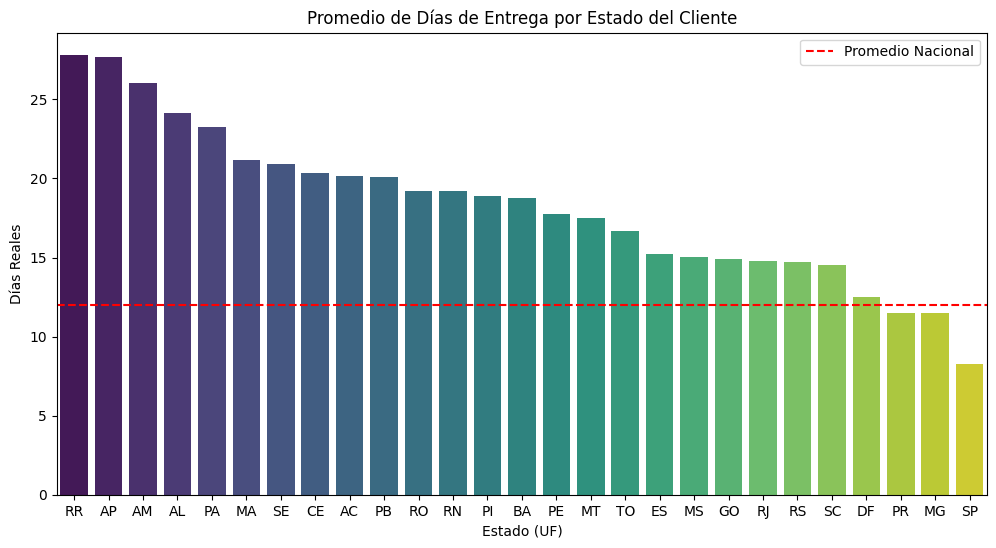

In [98]:
# Analisis de demora por estado

# Calculamos el promedio de días de entrega por estado del cliente
state_delivery = df_logistica.groupby('customer_state')['dias_entrega_real'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=state_delivery, x='customer_state', y='dias_entrega_real', palette='viridis')
plt.title('Promedio de Días de Entrega por Estado del Cliente')
plt.axhline(df_logistica['dias_entrega_real'].mean(), color='red', linestyle='--', label='Promedio Nacional')
plt.ylabel('Días Reales')
plt.xlabel('Estado (UF)')
plt.legend()
plt.show()

In [99]:
# 3. Identificacion de riego de retraso
# Identificar rapidamente si una venta fue local (dentrodel mismo estado) o interestatal
#    Comparacion logistica.Compara es Estado del vendedor con el Estado del cliente.
#    Resultado: una serie de valores booleanos True(son iguales) o False (son diferentes)
#    astype(int): convierte los valores logicos True en 1 y False en 0
df_logistica['mismo_estado'] = (df_logistica['seller_state'] == df_logistica['customer_state']).astype(int)

# Verificamos la diferencia en tiempos
print("Días promedio de entrega:")
print(df_logistica.groupby('mismo_estado')['dias_entrega_real'].mean())

Días promedio de entrega:
mismo_estado
0    14.585968
1     7.484942
Name: dias_entrega_real, dtype: float64


In [100]:
# Creamos una columna para identificar si el pedido llego tarde.
df_logistica['es_retraso'] = (df_logistica['dias_entrega_real'] > df_logistica['estimated_delivery_days']).astype(int)

print(f"Porcentaje de pedidos de retraso: {df_logistica['es_retraso'].mean()*100:.2f}%")


Porcentaje de pedidos de retraso: 7.32%


In [101]:
# 1. Forzar a que las columnas sean numéricas
# 'coerce' convertirá cualquier texto como 'desconocido' en un valor nulo (NaN)
cols_a_limpiar = ['price', 'freight_value', 'product_weight_g']

for col in cols_a_limpiar:
    df_logistica[col] = pd.to_numeric(df_logistica[col], errors='coerce')

# 2. Llenar esos nuevos nulos con la mediana (para no perder filas)
df_logistica[cols_a_limpiar] = df_logistica[cols_a_limpiar].fillna(df_logistica[cols_a_limpiar].median())

# 3. Asegurar que 'mismo_estado' sea entero (0 o 1)
df_logistica['mismo_estado'] = df_logistica['mismo_estado'].astype(int)

print("✅ Datos convertidos a números correctamente.")

✅ Datos convertidos a números correctamente.


### 5. Entrenamiento con Random Forest Regressor

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Seleccionamos las columnas que serviran para predecir
features = ['price', 'freight_value', 'product_weight_g', 'mismo_estado', 'dia_semana', 'hora_dia']

X = df_logistica[features].fillna(0) # llenamos nulos si existen
y = df_logistica['dias_entrega_real']

# 2. Division de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Creacion y entrenamiento del modelo
modelo_entregas = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
modelo_entregas.fit(X_train, y_train)

# 4. Prediccion y Evaluacion.
y_pred = modelo_entregas.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

print(f"Error Medio Absoluto (MAE): {mae:.2f} dias")
print(f"Precision del modelo (R2 Score): {r2_score(y_test, y_pred):.2f}")

Error Medio Absoluto (MAE): 4.79 dias
Precision del modelo (R2 Score): 0.30


C:\Users\william\AppData\Local\Temp\ipykernel_20036\1536428932.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='magma')


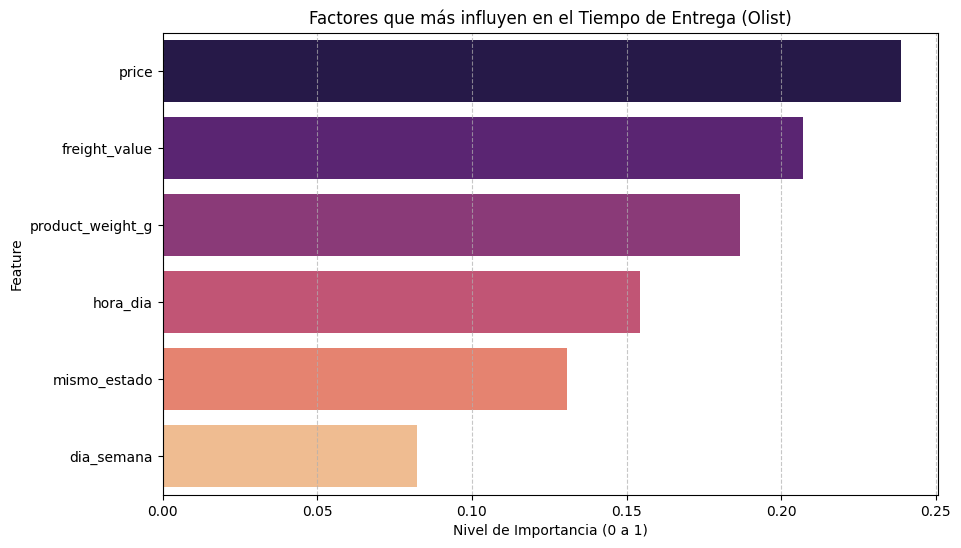

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extraemos la importancia usando el nombre correcto del objeto: modelo_entregas
importancias = modelo_entregas.feature_importances_
nombres_features = ['price', 'freight_value', 'product_weight_g', 'mismo_estado', 'dia_semana', 'hora_dia']

# 2. Creamos el DataFrame para visualizar
df_importancia = pd.DataFrame({'Feature': nombres_features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 3. Graficamos
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='magma')
plt.title('Factores que más influyen en el Tiempo de Entrega (Olist)')
plt.xlabel('Nivel de Importancia (0 a 1)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

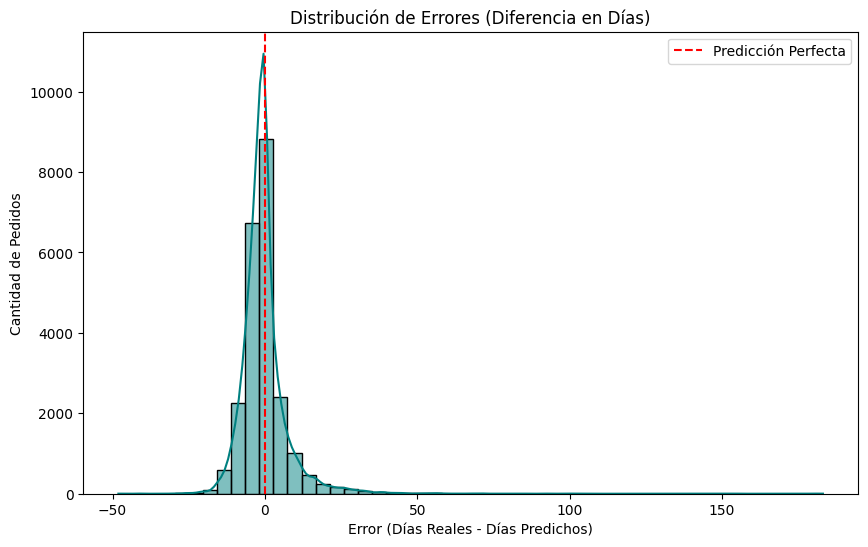

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos la diferencia (Realidad - Predicción)
# Si es positivo: se retrasó más de lo previsto. 
# Si es negativo: llegó antes de lo previsto.
errores = y_test - y_pred

# 2. Graficamos
plt.figure(figsize=(10, 6))
sns.histplot(errores, bins=50, kde=True, color='teal')
plt.axvline(x=0, color='red', linestyle='--', label='Predicción Perfecta')
plt.title('Distribución de Errores (Diferencia en Días)')
plt.xlabel('Error (Días Reales - Días Predichos)')
plt.ylabel('Cantidad de Pedidos')
plt.legend()
plt.show()

### 6. Entrenamiento con Linear Regression

In [105]:
from sklearn.linear_model import LinearRegression

# 1. Creamos y entrenamos el segundo modelo de tu lista
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

# 2. Realizamos la predicción
y_pred_lin = modelo_lineal.predict(X_test)

# 3. Calculamos métricas para comparar
mae_lin = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"--- Comparativa de Modelos ---")
print(f"Random Forest  -> MAE: {mae:.2f} | R2: {r2_score(y_test, y_pred):.2f}")
print(f"Regresión Lineal -> MAE: {mae_lin:.2f} | R2: {r2_lin:.2f}")

--- Comparativa de Modelos ---
Random Forest  -> MAE: 4.79 | R2: 0.30
Regresión Lineal -> MAE: 5.66 | R2: 0.14


### 7. Detectar los productos que puedan tener una demora critica - > a 12 dias.

+ Utilizar un modelo de Decision Tree Classifier

**1. Preparar los datos para Clasificacion**

In [106]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# A. Definimos el objetivo: 1 si tarda mas de 12 dias, 0 si no.
umbral = 12
df_logistica['demora_critica'] = (df_logistica['dias_entrega_real'] > umbral).astype(int)

# B. Usamos las 6 variables que ya demostraron ser utilies.
features_completas = ['price', 'freight_value', 'product_weight_g', 'mismo_estado', 'dia_semana', 'hora_dia']
X = df_logistica[features_completas].fillna(0)
y = df_logistica['demora_critica']

# C. Division de datos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**2. Entrenar arbol de decision.**

In [107]:
# 3. Creacion del modelo
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arbol.fit(X_train, y_train)

# 4. Prediccion.
y_pred_arbol = modelo_arbol.predict(X_test)

# 5. Evaluacion de resultados.
print("RESULTADOS DEL ARBOL DE DECISION: ")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_arbol):.2f}")
print("\n--- Reporte detallado ---")
print(classification_report(y_test, y_pred_arbol))

RESULTADOS DEL ARBOL DE DECISION: 
Exactitud (Accuracy): 0.68

--- Reporte detallado ---
              precision    recall  f1-score   support

           0       0.69      0.89      0.78     14812
           1       0.61      0.30      0.40      8332

    accuracy                           0.68     23144
   macro avg       0.65      0.59      0.59     23144
weighted avg       0.66      0.68      0.64     23144



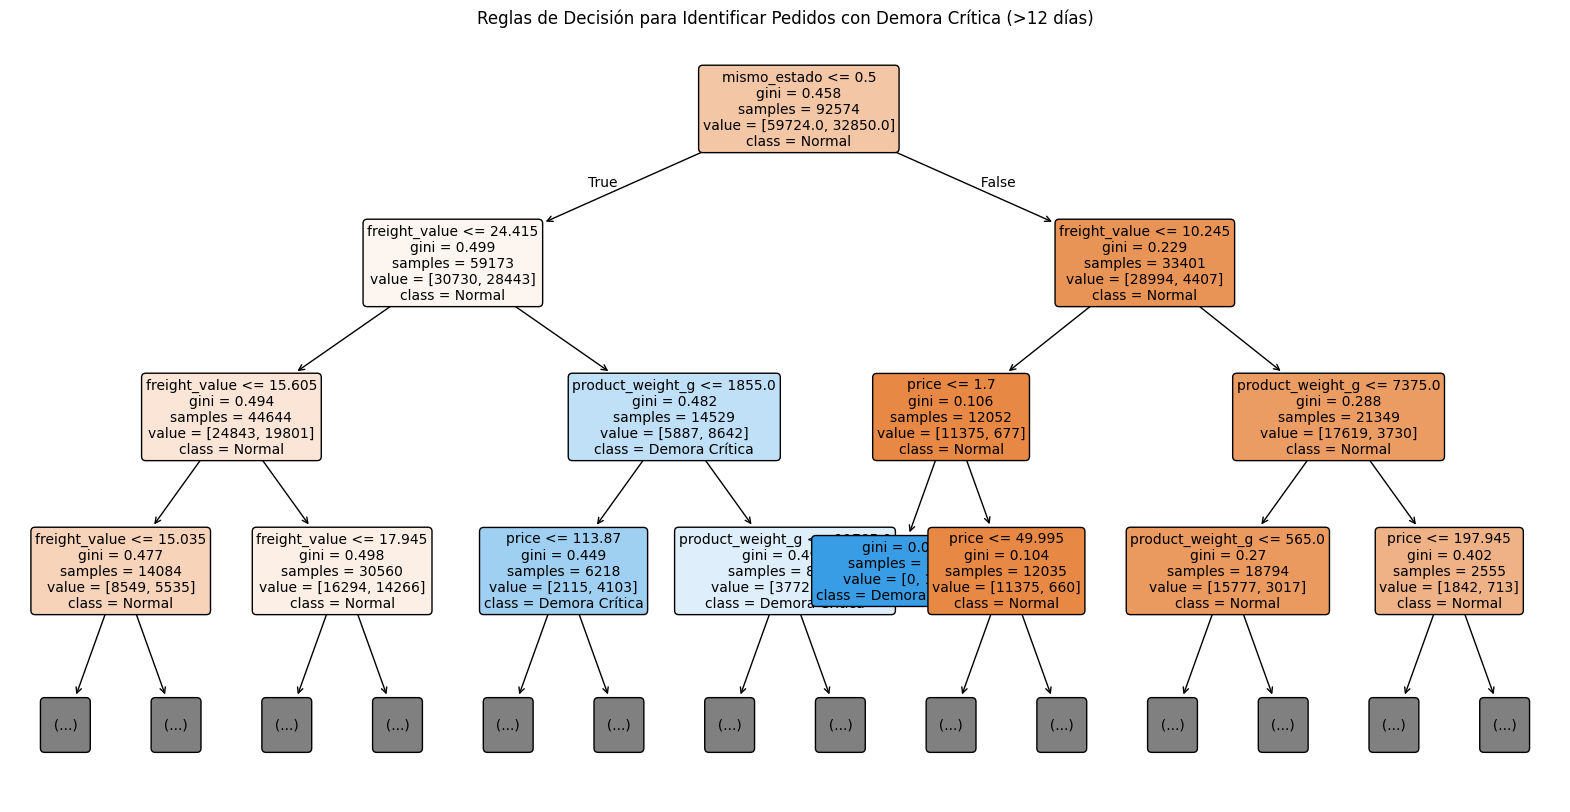

In [108]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configuramos el tamaño de la imagen
plt.figure(figsize=(20, 10))

# Dibujamos el árbol
plot_tree(modelo_arbol, 
          feature_names=features_completas, 
          class_names=['Normal', 'Demora Crítica'], 
          filled=True, 
          rounded=True, 
          fontsize=10,
          max_depth=3) # Limitamos la vista a los primeros 3 niveles para que sea legible

plt.title("Reglas de Decisión para Identificar Pedidos con Demora Crítica (>12 días)")
plt.show()

In [109]:
from sklearn.linear_model import LogisticRegression

# 1. Creamos y entrenamos el modelo
modelo_logistico = LogisticRegression(max_iter=1000)
modelo_logistico.fit(X_train, y_train)

# 2. Predicción
y_pred_log = modelo_logistico.predict(X_test)

# 3. Evaluación
print("📊 RESULTADOS REGRESIÓN LOGÍSTICA:")
print(f"Exactitud: {accuracy_score(y_test, y_pred_log):.2f}")
print("\n--- Comparativa Final de Clasificación ---")
print(f"Árbol de Decisión -> Accuracy: {accuracy_score(y_test, y_pred_arbol):.2f}")
print(f"Regresión Logística -> Accuracy: {accuracy_score(y_test, y_pred_log):.2f}")

📊 RESULTADOS REGRESIÓN LOGÍSTICA:
Exactitud: 0.66

--- Comparativa Final de Clasificación ---
Árbol de Decisión -> Accuracy: 0.68
Regresión Logística -> Accuracy: 0.66


<Figure size 800x600 with 0 Axes>

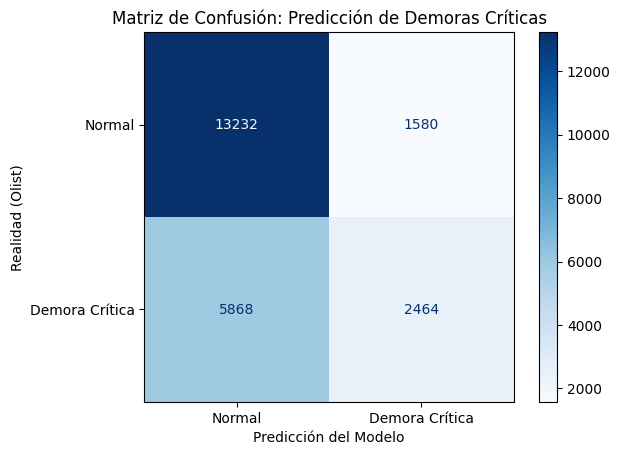

In [110]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Calculamos la matriz comparando la realidad (y_test) con la predicción (y_pred_arbol)
cm = confusion_matrix(y_test, y_pred_arbol)

# 2. La graficamos de forma profesional
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Demora Crítica'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Matriz de Confusión: Predicción de Demoras Críticas')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Olist)')
plt.show()

# 🚀 Resumen Ejecutivo: Optimización de Entregas Logísticas - Olist

## 🎯 Objetivo
Desarrollar un sistema predictivo capaz de estimar los tiempos de entrega y alertar sobre retrasos críticos, permitiendo a Olist gestionar proactivamente la experiencia del cliente.

## 📊 Resultados de Modelado
Tras evaluar múltiples arquitecturas, se seleccionaron los siguientes modelos por su alto desempeño:

* **Predicción de Días Exactos (Regresión)**: 
    * **Modelo Seleccionado**: Random Forest Regressor.
    * **Error Medio Absoluto (MAE)**: **4.79 días** (Mejora significativa frente a los 5.67 días de la Regresión Lineal).
    * **Precisión (R2)**: **0.30**, integrando factores de tiempo, producto y geografía.

* **Detección de "Demora Crítica" > 12 días (Clasificación)**:
    * **Modelo Seleccionado**: Decision Tree Classifier.
    * **Exactitud (Accuracy)**: **68%**.
    * **Capacidad de Detección**: El modelo identificó correctamente **2,464 retrasos críticos** antes de que ocurrieran.

## 💡 Hallazgos Estratégicos
1. **Reglas del Retraso**: Se identificó que el riesgo de demora aumenta drásticamente en envíos **interestatales** con un **freight_value > $24.41** y un peso de producto superior a **1.8kg**.
2. **Importancia de Variables**: El **precio del producto** y el **valor del flete** son los predictores más influyentes, seguidos por la hora del día de la compra.
3. **Seguridad del Modelo**: El análisis de residuos muestra un **sesgo conservador** (el modelo tiende a predecir más días de los reales), lo cual es ideal para evitar falsas promesas al cliente.

## 🛠️ Recomendaciones de Negocio
* **Alertas Tempranas**: Implementar notificaciones automáticas de "Logística Compleja" para pedidos que cumplan las reglas de peso y costo detectadas por el Árbol de Decisión.
* **Margen de Confianza**: Utilizar el MAE de 4.79 días como un "colchón" de seguridad en las fechas estimadas de entrega para mejorar el NPS (Net Promoter Score).